# Half-system entanglement-energy histogram
Raw pooled counts for 100 pure-state endpoints at cycle 64, hard walls, $20\times32$, $\alpha_1=1$, and $A_y=16$. Include all 32 periodic cut origins. Origins are correlated within a trajectory; there are 100 independent trajectories.

For centered occupation $\lambda=2\nu-1$, the signed single-particle entanglement energy is
$$\varepsilon=\log[(1-\nu)/\nu]=\log[(1-\lambda)/(1+\lambda)]=-2\operatorname{artanh}\lambda.$$
Retain $|\lambda|\le L=0.99$ before transforming, so $|\varepsilon|\le\log199\simeq5.2933$. Its magnitude equals $2\omega$ in the paper's convention. These are single-particle energies, not many-body levels. No clipping or density normalization is applied. Every retained mode for each trajectory and origin contributes one count. Pooling changes the vertical factor relative to averaging, not the shape.

In [1]:
import os
CPU_RANGE=(8,15) # Editable inclusive CPU range.
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):
    os.environ[key]=str(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15]


## Configuration and input provenance
Use the validated spectra cache; no dynamics or diagonalization is repeated.

In [2]:
from pathlib import Path
import json,hashlib,subprocess
import numpy as np
import pandas as pd
from IPython.display import display,Image
OUT=Path.cwd()
SOURCE=OUT.parent/'centered_spectral_window_origin_averaged_n20x32_hard_alpha1_v2/subsystem_spectra.npz'
PRIOR=OUT.parent/'mean_mode_count_window_scan_n20x32_v1'
L=0.99
AY=16
provenance=json.loads((PRIOR/'input_provenance.json').read_text())
source_sha=hashlib.sha256(SOURCE.read_bytes()).hexdigest()
assert source_sha==provenance['configuration']['spectrum_cache_sha256']
with np.load(SOURCE) as z:
    lam=z[f'eigenvalues_Ay{AY:02d}']
    sample_ids=z['sample_ids'];origins=z['origins']
assert lam.shape==(100,32,40*AY)
assert np.array_equal(sample_ids,np.arange(100))
assert np.array_equal(origins,np.arange(32))
assert np.isfinite(lam).all() and np.max(np.abs(lam))<=1+1e-8
metadata={'Nx':20,'Ny':32,'Ay':AY,'samples':100,'origins':32,'cycle':64,
          'construction':'hard','alpha_1':1,'L':L,'source':str(SOURCE),
          'source_sha256':source_sha,'source_bytes':SOURCE.stat().st_size,
          'estimator':'raw counts pooled over trajectories and origins; no normalization',
          'energy_convention':'epsilon=log(1-lambda)-log(1+lambda); |epsilon|=2 omega'}
display(pd.Series(metadata))
(OUT/'input_provenance.json').write_text(json.dumps({'analysis':metadata,'parent_provenance':provenance},indent=2)+'\n')

Nx                                                                  20
Ny                                                                  32
Ay                                                                  16
samples                                                            100
origins                                                             32
cycle                                                               64
construction                                                      hard
alpha_1                                                              1
L                                                                 0.99
source               /home/abhuiyan/class_A_fermionic_adaptive_circ...
source_sha256        8cd3aa2eee6df5a92d958f9df2025e530d9a3d62c9e33e...
source_bytes                                                  54868726
estimator            raw counts pooled over trajectories and origin...
energy_convention    epsilon=log(1-lambda)-log(1+lambda); |epsilon|...
dtype:

16968

## Transform the retained modes
The occupation-window selection is applied separately to every cached spectrum. Compare the retained counts with the previous window-count analysis.

In [3]:
assert 0<L<1
mask=np.abs(lam)<=L
sample_index,origin_index,mode_index=np.nonzero(mask)
retained_lambda=lam[mask]
energy=np.log1p(-retained_lambda)-np.log1p(retained_lambda)
energy_limit=float(np.log1p(L)-np.log1p(-L))
assert np.isfinite(energy).all()
assert np.all(np.abs(energy)<=energy_limit)
assert np.allclose(-np.tanh(energy/2),retained_lambda,rtol=0,atol=5e-16)
with np.load(PRIOR/'window_scan_statistics.npz') as z:
    li=np.flatnonzero(np.isclose(z['L_values'],L,rtol=0,atol=1e-14))[0]
    ai=np.flatnonzero(z['widths']==AY)[0]
    assert np.array_equal(mask.sum(-1),z['counts'][:,li,ai,:])
np.savez_compressed(OUT/'retained_entanglement_energies.npz',
    energy=energy,centered_occupation=retained_lambda,
    sample_id=sample_ids[sample_index],origin_y=origins[origin_index],mode_index=mode_index,
    retained_counts_by_sample_origin=mask.sum(-1),L=L,Ay=AY)
print(f'Retained {energy.size:,} mode observations; mean per cut = {mask.sum(-1).mean():.6f}')

Retained 95,398 mode observations; mean per cut = 29.811875


## Raw histogram
Equal-width energy bins, linear axes. Edit the bin count below without reloading spectra or recalculating energies.

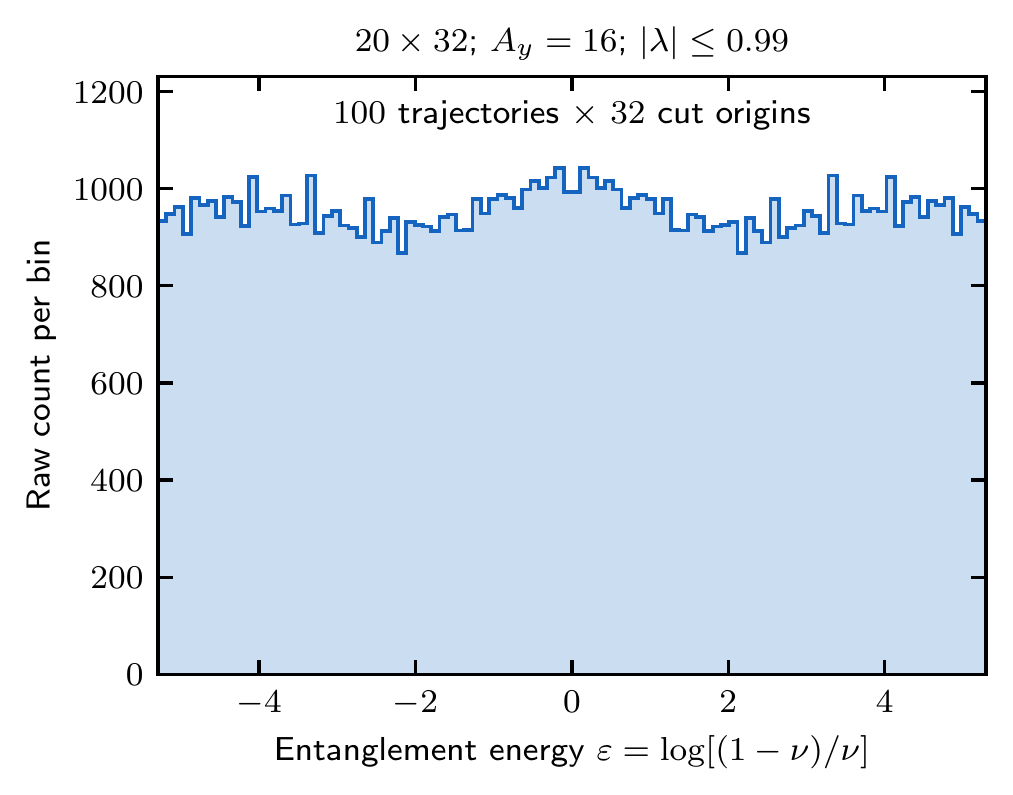

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
BINS=100
edges=np.linspace(-energy_limit,energy_limit,BINS+1)
counts,edges=np.histogram(energy,bins=edges)
assert counts.sum()==energy.size
pd.DataFrame({'energy_left':edges[:-1],'energy_right':edges[1:],
              'energy_center':(edges[:-1]+edges[1:])/2,'count':counts}).to_csv(OUT/'entanglement_energy_histogram.csv',index=False)
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],
 'font.size':8,'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,
 'text.usetex':True,'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in'})
fig,ax=plt.subplots(figsize=(3.375,2.65))
ax.stairs(counts,edges,fill=True,color='#1565c0',alpha=.22)
ax.stairs(counts,edges,color='#1565c0',linewidth=.9)
ax.set(xlabel=r'Entanglement energy $\varepsilon=\log[(1-\nu)/\nu]$',
       ylabel='Raw count per bin',xlim=(-energy_limit,energy_limit),ylim=(0,None),
       title=r'$20\times32$; $A_y=16$; $|\lambda|\leq0.99$')
ax.tick_params(top=True,right=True)
ax.text(.5,.96,r'$100$ trajectories $\times$ $32$ cut origins',ha='center',va='top',transform=ax.transAxes,fontsize=8)
ax.set_ylim(0,counts.max()*1.18)
fig.tight_layout(pad=.8)
fig.savefig(OUT/'entanglement_energy_histogram.pdf')
plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'entanglement_energy_histogram.pdf'),str(OUT/'entanglement_energy_histogram')],check=True)
display(Image(filename=str(OUT/'entanglement_energy_histogram.png'),width=650))

## Numerical diagnostics
The histogram total must equal the retained mode count. The inverse energy transform and the prior mode-count cache are checked above.

In [5]:
diagnostics={**metadata,'energy_limit':energy_limit,'bins':BINS,
 'total_mode_observations':int(lam.size),'retained_mode_observations':int(energy.size),
 'excluded_mode_observations':int(lam.size-energy.size),'histogram_total':int(counts.sum()),
 'mean_retained_modes_per_cut':float(mask.sum(-1).mean()),
 'energy_min':float(energy.min()),'energy_max':float(energy.max()),
 'counts_match_previous_analysis':True,'normalization':'none'}
(OUT/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(pd.Series(diagnostics))

Nx                                                                               20
Ny                                                                               32
Ay                                                                               16
samples                                                                         100
origins                                                                          32
cycle                                                                            64
construction                                                                   hard
alpha_1                                                                           1
L                                                                              0.99
source                            /home/abhuiyan/class_A_fermionic_adaptive_circ...
source_sha256                     8cd3aa2eee6df5a92d958f9df2025e530d9a3d62c9e33e...
source_bytes                                                               5